# W01 Mon — Setup and Orientation
## IIT414W · Unit I · Week 1 · Mon March 2, 2026

**Learning goals for this session:**
- Verify Python, conda/pip, Jupyter, and Git are correctly installed.
- Clone the course repo and run a reproducibility check.
- Understand the vibe-coder vs. agentic-engineer spectrum.
- Make a F1 winner prediction (intuition-based, no model) and document it.

**Before you start:** Confirm your environment is created from `environment.yml` or `requirements.txt` and that Git is available in your terminal.



In [1]:
# ── Reproducibility Header ────────────────────────────────────────────
# Every notebook in IIT414W starts here. Do not skip this block.

import sys, random
import numpy as np
import warnings

RANDOM_SEED = 414  # Course constant. Do not change.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

# Environment check
print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'Seed    : {RANDOM_SEED}')


Python  : 3.13.12
NumPy   : 2.2.5
Seed    : 414


In [2]:
# ── Dependency Guard ───────────────────────────────────────────────
# Ensures all required packages are installed in the active kernel.
# Safe to re-run: pip will skip already-installed packages.

import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'fastf1': 'fastf1',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done. Packages installed successfully.')
else:
    print('All required packages already installed ✓')

# ── Library Imports ───────────────────────────────────────────────
import os                        # Working directory checks
import subprocess                # Git command checks
import importlib                 # Runtime dependency checks
import numpy as np               # Numeric support
import pandas as pd              # Tables and diagnostics
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical plotting
import fastf1                    # Formula 1 data access

print(f'fastf1  : {fastf1.__version__}')
print(f'pandas  : {pd.__version__}')

All required packages already installed ✓
fastf1  : 3.8.1
pandas  : 2.2.3


## 1. Environment Verification

**The idea.** We verify that the full local toolchain works before any analysis.

**In F1 terms.** A team validates telemetry feeds before strategy simulation.

> **Why it matters:** Setup problems masquerade as modeling mistakes if not checked first.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > How will we prove this machine can reproduce course notebooks from scratch?

2. **What does success look like? How will we know if the result is good?**
   > Success means a fresh environment can run the notebook to to bottom without manual fixes and it produces the expected version checks/outputs consistently

3. **What could go wrong? Name one failure mode.**
   > A key package/version mismatch causes cells to fail or produce different outputs.


In [3]:
required = ['numpy', 'pandas', 'sklearn', 'matplotlib', 'seaborn', 'fastf1']
rows = []
for pkg in required:
    mod = importlib.import_module(pkg)
    rows.append((pkg, getattr(mod, '__version__', 'n/a')))

print(pd.DataFrame(rows, columns=['package', 'version']).to_string(index=False))
print(f'Working directory: {os.getcwd()}')

# FastF1 cache — auto-create if missing
cache_path = os.path.join(os.path.dirname(os.getcwd()), '..', 'data', 'fastf1_cache')
cache_path = os.path.abspath(cache_path)
os.makedirs(cache_path, exist_ok=True)
fastf1.Cache.enable_cache(cache_path)
print(f'FastF1 cache enabled: {cache_path}')

print(subprocess.run(['git', '--version'], capture_output=True, text=True, check=False).stdout.strip())
log = subprocess.run(['git', 'log', '--oneline', '-5'], capture_output=True, text=True, check=False)
print('Recent commits:')
print(log.stdout.strip() if log.returncode == 0 else 'No commit history available in this folder.')

   package version
     numpy   2.2.5
    pandas   2.2.3
   sklearn   1.7.2
matplotlib  3.10.3
   seaborn  0.13.2
    fastf1   3.8.1
Working directory: C:\Users\joaqu\OneDrive\Documentos\GitHub\iit414w-lab00-JoacoRW
FastF1 cache enabled: C:\Users\joaqu\OneDrive\Documentos\data\fastf1_cache
git version 2.50.1.windows.1
Recent commits:
No commit history available in this folder.


In [4]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Run one additional system check and explain why it supports reproducibility.
# Expected output: A short printout plus one risk note.
# Hint: You can check `sys.executable`, platform info, or free disk space.

import platform

print('System check for reproducibility:')
print(f'Python executable: {sys.executable}')
print(f'Platform: {platform.system()} {platform.release()} ({platform.machine()})')

print(
    'Risk note: If a different interpreter/path is used on another machine, '
    'package versions and results may differ.'
)


System check for reproducibility:
Python executable: C:\Users\joaqu\OneDrive\Documentos\GitHub\iit414w-lab00-JoacoRW\.venv\Scripts\python.exe
Platform: Windows 11 (AMD64)
Risk note: If a different interpreter/path is used on another machine, package versions and results may differ.


In [5]:
# ── REFERENCE IMPLEMENTATION ──────────────────────────────────────
# This cell is intentionally left sparse in the student version.
# See solutions/ branch for full implementation.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

I was surprised by how much reproducibility depends on environment details, not just code correctness.

2. **Where could this technique fail or mislead you?**

This technique can give a false sense of confidence if we only check interpreter path and OS but skip exact package versions, hardware differences, or hidden config files.

3. **How would you explain this to a non-technical teammate?**

I’d explain it like a recipe: we are confirming we’re using the same kitchen and ingredients before cooking.


## 2. The Vibe Coder vs. Agentic Engineer

**The idea.** Agentic workflows require explicit decisions, checks, and evidence.

**In F1 terms.** Race engineers never trust a single number without validating context and assumptions.

> **Why it matters:** Decision quality, not code volume, is what we grade in this course.


### Spectrum Examples — Code Snippets

**Example 1 — AI suggests a train/test split:**

Vibe Coder:
```python
# AI says: just use train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# "Looks fine!" → ships it
```

Agentic Engineer:
```python
# Wait — is this temporal data? Random split could leak future info.
# Check: are there date columns? Is order meaningful?
print(df['year'].unique())  # 2019, 2020, 2021, 2022, 2023
# → Random split mixes years. Must split by time, not randomly.
```

**Example 2 — Model accuracy is 92%:**

Vibe Coder:
```python
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")  # 0.92
# "Great score!" → done
```

Agentic Engineer:
```python
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")  # 0.92
print(f"Majority baseline: {y_test.mean():.2f}")          # 0.90
# → Only 2% above always-predicting-majority. Basically useless.
```

**Example 3 — AI generates a feature engineering function:**

Vibe Coder:
```python
# Copies AI output directly into pipeline → no validation
def engineer_features(df):
    df['avg_position'] = df.groupby('driver')['position'].transform('mean')
    return df  # Uses future races to compute mean → leakage!
```

Agentic Engineer:
```python
# Before using: Does this use future information?
# 'mean' over ALL rows includes future races → target leakage!
# Fix: use expanding mean up to current race only
df['avg_position'] = df.groupby('driver')['position'].transform(
    lambda x: x.shift(1).expanding().mean()
)
```

| Scenario | Vibe Coder | Agentic Engineer |
|---|---|---|
| AI suggests code | Copies and runs | Tests assumptions and edge cases |
| Plot looks clean | Accepts narrative | Verifies labels, units, and sampling |
| Metric improves | Declares success | Checks leakage and baseline comparisons |

### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > Which one of your current coding habits is most likely to create silent errors?

2. **What does success look like? How will we know if the result is good?**
   > Success means I can name one specific habit, show a concrete example of how it creates a hidden mistake, and define one check I will use to catch it in future work.

3. **What could go wrong? Name one failure mode.**
   > I choose a habit that sounds good but is too vague.


In [6]:
self_check = pd.DataFrame(
    {
        'statement': [
            'I define success metrics before coding',
            'I verify train/val/test leakage explicitly',
            'I validate AI-generated code before reuse',
            'I document failed attempts',
            'I justify every modeling decision in writing',
        ],
        'score_1_to_5': [None, None, None, None, None],
    }
)
print(self_check.to_string(index=False))


                                   statement score_1_to_5
      I define success metrics before coding         None
  I verify train/val/test leakage explicitly         None
   I validate AI-generated code before reuse         None
                  I document failed attempts         None
I justify every modeling decision in writing         None


In [7]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Fill the checklist and write one concrete action to improve your lowest-scoring item.
# Expected output: A completed table and one action sentence.
# Hint: Honest scoring is more useful than optimistic scoring.

self_check['score_1_to_5'] = [4, 2, 4, 2, 5]
display(self_check)

print('I should set up a better validation process and document the results')

,statement,score_1_to_5
0,I define success metrics before coding,4
1,I verify train/val/test leakage explicitly,2
2,I validate AI-generated code before reuse,4
3,I document failed attempts,2
4,I justify every modeling decision in writing,5


I should set up a better validation process and document the results


In [8]:
# ── REFERENCE IMPLEMENTATION ──────────────────────────────────────
# This cell is intentionally left sparse in the student version.
# See solutions/ branch for full implementation.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

I learn that i dont have the habit to document or validate the leakage, so i should do it.

2. **Where could this technique fail or mislead you?**
If I only focus on one habit, I might miss other equally important ones.

3. **How would you explain this to a non-technical teammate?**
I would explain that this is like life, you always need to know that something could go wrong, so you should kept that info for future analisis.


## 3. Your First F1 Data Pull

**The idea.** We pull real FastF1 data and inspect lap-level structure before modeling.

**In F1 terms.** This is like opening timing screens before deciding race strategy.

> **Why it matters:** Early data literacy prevents poor feature assumptions later.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > What pattern do you expect to see in top-driver qualifying lap distributions?

2. **What does success look like? How will we know if the result is good?**
   > Success means the lap time distributions for top drivers show a clear, interpretable structure.

3. **What could go wrong? Name one failure mode.**
   > A failure mode is mixing non comparable laps with true push laps.


core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '55', '27', '1', '10', '63', '14', '77', '11', '22', '30', '18', '16', '20', '23', '24', '44', '43', '61']


First 5 laps for VER:
Driver  LapNumber                LapTime Compound
   VER        2.0 0 days 00:01:23.516000     SOFT
   VER        3.0 0 days 00:01:56.133000     SOFT
   VER        5.0 0 days 00:01:23.612000     SOFT
   VER        6.0 0 days 00:01:35.987000     SOFT
   VER        8.0 0 days 00:01:22.998000     SOFT


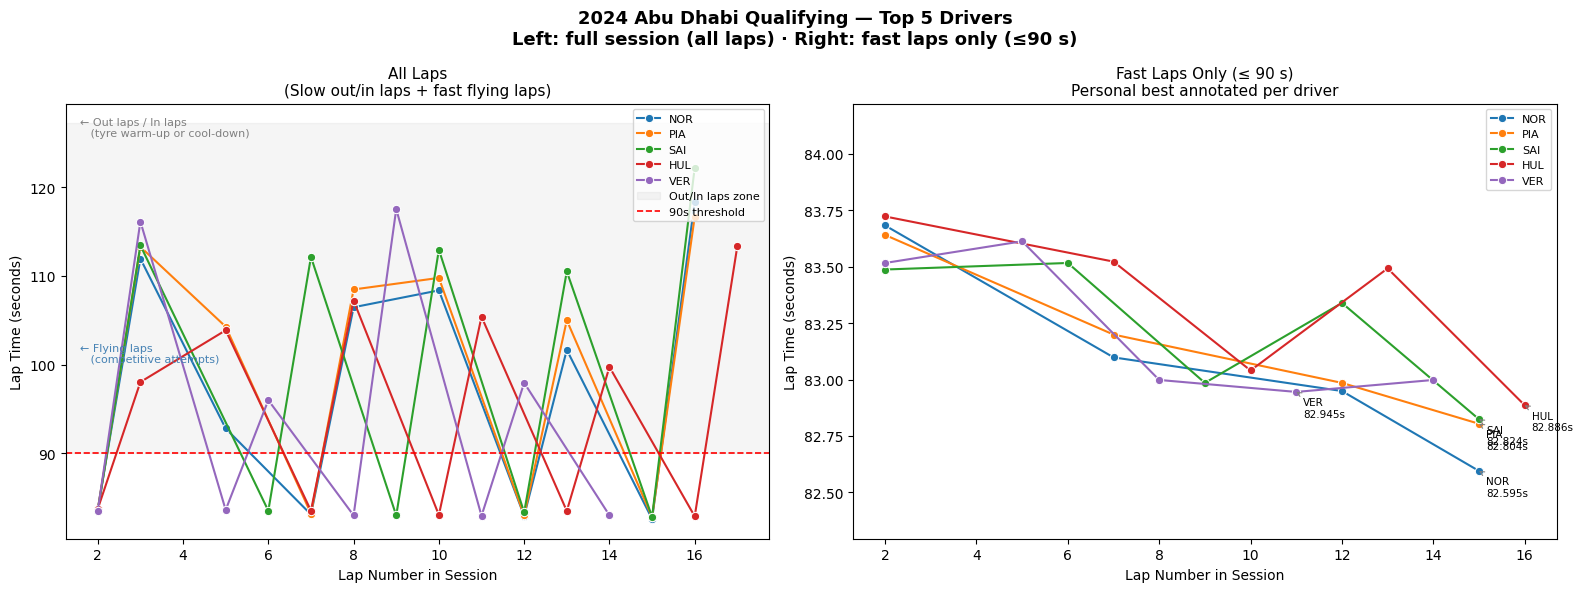


── Best Qualifying Lap per Driver (Top 5) ──
Driver  BestLapSec  GapToPole
   NOR      82.595      0.000
   PIA      82.804      0.209
   SAI      82.824      0.229
   HUL      82.886      0.291
   VER      82.945      0.350

💡 GapToPole: how many seconds behind the fastest qualifier each driver was.


In [9]:
# ── Load a Formula 1 Session ──────────────────────────────────────────────────
# fastf1.get_session() identifies a session by: year, event name (or round number), and session type.
# Session types: 'FP1', 'FP2', 'FP3' (Free Practice), 'Q' (Qualifying), 'R' (Race), 'S' (Sprint)
# 'Abu Dhabi' is the final race of the 2024 F1 season (Round 24).
session = fastf1.get_session(2024, 'Abu Dhabi', 'Q')

# session.load() fetches data from the FastF1 cache (or downloads it if not cached).
# We only need lap data here, so we disable the heavier telemetry/weather/messages
# to speed up loading. Set any of these to True if you need that data later.
#   laps=True      → lap-by-lap timing data (required for this analysis)
#   telemetry=False → car sensor data (speed, throttle, brake, gear) — not needed here
#   weather=False   → track temperature, wind, rain data — not needed here
#   messages=False  → race control messages (flags, penalties) — not needed here
session.load(laps=True, telemetry=False, weather=False, messages=False)

# ── Inspect VER (Max Verstappen) Lap Data ─────────────────────────────────────
# session.laps returns a special FastF1 DataFrame (Laps object) with all drivers.
# pick_drivers('VER') filters by driver abbreviation (3-letter code used in F1 broadcasts).
# Common abbreviations: NOR=Norris, VER=Verstappen, HAM=Hamilton, LEC=Leclerc, etc.
# LapTime is stored as a pandas Timedelta (days + HH:MM:SS.microseconds), not a float.
# dropna() removes laps where any selected column has missing data (e.g. aborted laps).
ver_laps = session.laps.pick_drivers('VER')[['Driver', 'LapNumber', 'LapTime', 'Compound']].dropna().head(5)
print('First 5 laps for VER:')
print(ver_laps.to_string(index=False))

# ── Get the Top 5 Qualifiers from Official Results ────────────────────────────
# session.results is a DataFrame with one row per driver, containing official timing.
# In qualifying, Position=1 is pole position (fastest overall Q3 time).
# We copy it to avoid accidentally modifying the original session data.
res = session.results.copy()

# Position can sometimes be stored as a string or mixed type — coerce to numeric.
# errors='coerce' turns any non-numeric value into NaN instead of raising an error.
res['Position'] = pd.to_numeric(res['Position'], errors='coerce')

# nsmallest(5, 'Position') picks the 5 rows with the lowest (best) position numbers.
# 'Abbreviation' gives us the 3-letter driver codes we need for lap filtering.
top5 = res.nsmallest(5, 'Position')['Abbreviation'].tolist()

# ── Build Plotting DataFrame for Top 5 Drivers ───────────────────────────────
# pick_drivers() also accepts a list of abbreviations — it returns all laps for those drivers.
# We keep only the columns we need for plotting: driver name, lap number, and lap time.
# .copy() ensures we work on a fresh DataFrame and not a view (avoids SettingWithCopyWarning).
plot_df = session.laps.pick_drivers(top5)[['Driver', 'LapNumber', 'LapTime']].dropna().copy()

# Convert Timedelta → float (seconds) for easy plotting on a numeric Y axis.
# dt.total_seconds() works on Timedelta columns; e.g. 0 days 00:01:22.595 → 82.595
plot_df['LapTimeSec'] = plot_df['LapTime'].dt.total_seconds()

# ── Separate fast laps from slow laps for cleaner visualization ───────────────
# In qualifying, drivers do:
#   - OUT LAPS  : slow laps to warm up tyres before a fast attempt  (> ~90s here)
#   - FLYING LAPS: the actual timed competitive laps               (<= ~90s here)
#   - IN LAPS   : slow laps returning to the pit box               (> ~90s here)
# We use 90 seconds as a threshold — anything faster is likely a competitive lap.
# Abu Dhabi circuit lap record is ~82s, so 90s gives us a comfortable margin.
# NOTE: This threshold is circuit-specific. For Monaco (~74s lap record) you'd use ~85s;
#       for Monza (~80s) you might use ~88s. Always check before applying.
FAST_LAP_THRESHOLD = 90  # seconds — adjust if session is at a shorter/longer circuit

fast_laps = plot_df[plot_df['LapTimeSec'] <= FAST_LAP_THRESHOLD]
slow_laps = plot_df[plot_df['LapTimeSec'] > FAST_LAP_THRESHOLD]

# ── Plot: Two panels side by side ─────────────────────────────────────────────
# plt.subplots(1, 2) creates a figure with 1 row and 2 columns of Axes (subplots).
# figsize=(16, 6) sets the figure width=16 inches, height=6 inches.
# axes[0] = left panel, axes[1] = right panel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    '2024 Abu Dhabi Qualifying — Top 5 Drivers\n'
    'Left: full session (all laps) · Right: fast laps only (≤90 s)',
    fontsize=13, fontweight='bold'
)

# ── LEFT PANEL: All laps — shows the full qualifying rhythm ───────────────────
# This panel helps students understand the structure of a qualifying session:
# Q1 (all 20 cars) → Q2 (top 15) → Q3 (top 10), each separated by slow in/out laps.
ax = axes[0]

# sns.lineplot with hue='Driver' automatically assigns a different color per driver
# and draws a line connecting their laps in order. marker='o' adds a dot at each lap.
sns.lineplot(data=plot_df, x='LapNumber', y='LapTimeSec',
             hue='Driver', marker='o', ax=ax)

# axhspan shades a horizontal band between two Y values across the full X range.
# This visually marks the "slow lap" region (out laps and in laps).
# alpha=0.08 makes the shading very transparent so lines remain readable.
ax.axhspan(FAST_LAP_THRESHOLD, plot_df['LapTimeSec'].max() + 5,
           alpha=0.08, color='gray', label='Out/In laps zone')

# axhline draws a horizontal reference line at y=FAST_LAP_THRESHOLD.
# linestyle='--' = dashed line; this is the boundary between slow and fast laps.
ax.axhline(FAST_LAP_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
           label=f'{FAST_LAP_THRESHOLD}s threshold')

ax.set_title('All Laps\n(Slow out/in laps + fast flying laps)', fontsize=11)
ax.set_xlabel('Lap Number in Session')
ax.set_ylabel('Lap Time (seconds)')
ax.legend(fontsize=8, loc='upper right')

# ax.text with transform=ax.transAxes uses Axes-relative coordinates:
# (0, 0) = bottom-left corner, (1, 1) = top-right corner of the plot area.
# This keeps the annotation in the same relative position regardless of data range.
ax.text(0.02, 0.97, '← Out laps / In laps\n   (tyre warm-up or cool-down)',
        transform=ax.transAxes, fontsize=8, va='top', color='gray')
ax.text(0.02, 0.45, '← Flying laps\n   (competitive attempts)',
        transform=ax.transAxes, fontsize=8, va='top', color='steelblue')

# ── RIGHT PANEL: Fast laps only — reveals true pace comparison ────────────────
# Removing the out/in laps compresses the Y axis, making small differences
# between drivers (often < 0.5s in qualifying) clearly visible.
ax = axes[1]
sns.lineplot(data=fast_laps, x='LapNumber', y='LapTimeSec',
             hue='Driver', marker='o', ax=ax)

# Annotate the personal best lap for each driver.
# idxmin() returns the index label of the minimum value in the Series.
# ax.annotate() places a text label with an arrow pointing to the data point.
for driver in top5:
    driver_fast = fast_laps[fast_laps['Driver'] == driver]
    if driver_fast.empty:
        continue
    best_row = driver_fast.loc[driver_fast['LapTimeSec'].idxmin()]
    ax.annotate(
        f"{driver}\n{best_row['LapTimeSec']:.3f}s",  # .3f = 3 decimal places (millisecond precision)
        xy=(best_row['LapNumber'], best_row['LapTimeSec']),  # arrow tip: the actual data point
        xytext=(5, -18), textcoords='offset points',         # label offset in pixels from the tip
        fontsize=7.5, color='black',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
    )

ax.set_title('Fast Laps Only (≤ 90 s)\nPersonal best annotated per driver', fontsize=11)
ax.set_xlabel('Lap Number in Session')
ax.set_ylabel('Lap Time (seconds)')
ax.legend(fontsize=8, loc='upper right')

# Tighten y-axis so small differences between drivers are visible.
# Without this, matplotlib auto-scales to include 0 on the Y axis,
# making a 0.3s gap between pole and P5 almost invisible.
y_min = fast_laps['LapTimeSec'].min()
y_max = fast_laps['LapTimeSec'].max()
ax.set_ylim(y_min - 0.3, y_max + 0.5)  # small padding around the actual data range

# tight_layout() automatically adjusts subplot spacing to prevent label overlap.
plt.tight_layout()
plt.show()

# ── Summary table: Best lap per driver ────────────────────────────────────────
# This table makes it easy to compare pole-lap pace without reading from the chart.
print('\n── Best Qualifying Lap per Driver (Top 5) ──')
best_laps = (
    fast_laps.groupby('Driver')['LapTimeSec']
    .min()                                          # best (minimum) lap time per driver
    .reset_index()                                  # turn the groupby result back into a flat DataFrame
    .rename(columns={'LapTimeSec': 'BestLapSec'})
    .sort_values('BestLapSec')                      # sort fastest → slowest (pole position first)
)
# GapToPole: difference between each driver's best lap and the pole-sitter's best lap.
# iloc[0] is the pole-sitter after sort_values, so subtracting gives 0.000 for pole.
best_laps['GapToPole'] = (best_laps['BestLapSec'] - best_laps['BestLapSec'].iloc[0]).round(3)
print(best_laps.to_string(index=False))
print('\n💡 GapToPole: how many seconds behind the fastest qualifier each driver was.')


In [10]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Compare one additional driver against VER and summarize variance differences.
# Expected output: A table and one interpretation sentence.
# Hint: Use standard deviation of lap times in seconds.

compare_df = session.laps.pick_drivers(['VER', 'NOR'])[['Driver','LapTime']].dropna().copy()

compare_df['LapTimeSec'] = compare_df['LapTime'].dt.total_seconds()
variance_table = compare_df.groupby('Driver')['LapTimeSec'].agg(['mean', 'std']).reset_index()
variance_table.rename(columns={'mean': 'MeanLapTimeSec', 'std': 'StdDevLapTimeSec'}, inplace=True)

print("\n── Lap Time Variance Comparison (VER vs NOR) ──")
display(variance_table)

ver_std = variance_table.loc[variance_table['Driver']=='VER','StdDevLapTimeSec'].iloc[0]
nor_std = variance_table.loc[variance_table['Driver']=='NOR','StdDevLapTimeSec'].iloc[0]

if ver_std < nor_std:
    print("\nInterpretation: VER shows more consistent lap times than NOR (lower variance).")
else:
    print("\nInterpretation: NOR shows more consistent lap times than VER (lower variance).")



── Lap Time Variance Comparison (VER vs NOR) ──


,Driver,MeanLapTimeSec,StdDevLapTimeSec
0,NOR,97.190800,13.793983
1,VER,93.741222,14.338829



Interpretation: NOR shows more consistent lap times than VER (lower variance).


In [11]:
# ── REFERENCE IMPLEMENTATION ──────────────────────────────────────
# This cell is intentionally left sparse in the student version.
# See solutions/ branch for full implementation.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

One thing that surprised me was that Norris had a slightly lower standard deviation than Verstappen, meaning his lap times were a bit more consistent.

2. **Where could this technique fail or mislead you?**

This technique could be misleading if the lap times include slow laps such as out laps or in laps. These laps can increase the average lap time and the standard deviation, making the data look more variable than it really is.

3. **How would you explain this to a non-technical teammate?**

I would explain that we are comparing how fast and how consistent two drivers are during their laps.


## 4. Prediction Card Activity

**The idea.** We capture a structured forecast before formal modeling begins.

**In F1 terms.** Teams commit assumptions before race outcomes are known, then revisit them.

> **Why it matters:** Documented assumptions reduce hindsight bias and improve learning loops.


### Prediction Card (fill this markdown cell)

1. **Who will win the 2025 Drivers' Championship?**

Max Verstappen.

2. **What data would you use to support that prediction?**

I would use 2023 to 2025 qualifying pace, race pace consistency, pit stop performance, teammate comparison, and team development trend over the season.

3. **What could go wrong with your prediction?**

A major regulation or car development shift could change team performance, and one reliability streak or injury.

### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > What assumptions are you making about the 2025 championship winner right now?

2. **What does success look like? How will we know if the result is good?**
   > Success means I clearly state my assumptions and they are good enough to test later against real season outcomes.

3. **What could go wrong? Name one failure mode.**
   > One failure mode is over-weighting recent races and ignoring uncertainty.


In [12]:
prediction_card_template = {
    'predicted_2025_champion': '[fill in]',
    'evidence_plan': ['[feature/data source 1]', '[feature/data source 2]', '[feature/data source 3]'],
    'failure_modes': ['[risk 1]', '[risk 2]'],
}
print(prediction_card_template)


{'predicted_2025_champion': '[fill in]', 'evidence_plan': ['[feature/data source 1]', '[feature/data source 2]', '[feature/data source 3]'], 'failure_modes': ['[risk 1]', '[risk 2]']}


In [13]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Fill the prediction card in this notebook and keep it for Week 6 revisit.
# Expected output: A completed dictionary with explicit assumptions.
# Hint: Be specific about what could invalidate your prediction.

prediction_card_template = {
    "predicted_2025_champion": "Max Verstappen",
    "evidence_plan": [
        'Qualifying pace trend', 
        'Race pace and consistency', 
        'Reliability and execution metrics'
    ],
    "assumptions": [
        "Red Bull remains top 2 in race pace for most of the season",
        "No rival team gains a sustained, large development advantage by mid-season"
    ],
    "failure_modes": [
        'Major regulation or shift changes team performance', 
        'issues or injury'
    ]
}
display(prediction_card_template)


{'predicted_2025_champion': 'Max Verstappen',
 'evidence_plan': ['Qualifying pace trend',
  'Race pace and consistency',
  'Reliability and execution metrics'],
 'assumptions': ['Red Bull remains top 2 in race pace for most of the season',
  'No rival team gains a sustained, large development advantage by mid-season'],
 'failure_modes': ['Major regulation or shift changes team performance',
  'issues or injury']}

In [14]:
# ── REFERENCE IMPLEMENTATION ──────────────────────────────────────
# This cell is intentionally left sparse in the student version.
# See solutions/ branch for full implementation.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**
    > I was surprised by how many hidden assumptions are inside a simple prediction.
2. **Where could this technique fail or mislead you?**
    > This technique can mislead me if I become overconfident in assumptions that are hard to verify early in the season.
3. **How would you explain this to a non-technical teammate?**
    > It is like making a sports prediction: you do not only say who will win, you also say why you think that and what could make you wrong.


## 5. What Is Machine Learning? (Conceptual Anchor)

**The idea.** ML can be explained at intuitive, technical, and formal levels.

**In F1 terms.** A model is like a pit strategy simulator: useful under known conditions, fragile under shifts.

> **Why it matters:** Clear conceptual framing prevents wrong targets and wrong metrics.


### ML Taxonomy in F1

- **Supervised:** Predict Top-10 finish from pre-race features.
- **Unsupervised:** Cluster circuits by pace profile.
- **Reinforcement Learning:** Optimize pit timing via simulated reward.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > Which ML paradigm best matches each F1 task: winner prediction, circuit clustering, pit strategy optimization?

2. **What does success look like? How will we know if the result is good?**
   > Success means each task is matched to a paradigm with a clear justification.

3. **What could go wrong? Name one failure mode.**
   > A failure mode is forcing one paradigm onto all tasks, which can produce misleading results.


In [15]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=500, n_features=6, n_informative=4, random_state=RANDOM_SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(f'Synthetic supervised demo accuracy: {accuracy_score(y_test, pred):.3f}')


Synthetic supervised demo accuracy: 0.960


In [16]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Create a 3-row table: supervised, unsupervised, reinforcement learning with one F1 use case each.
# Expected output: A concise paradigm-to-use-case table.
# Hint: Include one risk if each paradigm is misapplied.

ml_map = pd.DataFrame(
    [
        {
            "paradigm": "Supervised",
            "f1_use_case": "Predict Top 10 race finish from pre race features",
            "risk_if_misapplied": "Data leakage can make accuracy look ultra high",
        },
        {
            "paradigm": "Unsupervised",
            "f1_use_case": "Cluster circuits by pace tyre degradation profile",
            "risk_if_misapplied": "Clusters may look meaningful but reflect noise or poor feature scaling",
        },
        {
            "paradigm": "Reinforcement Learning",
            "f1_use_case": "Optimize pit stop timing policy in race simulation",
            "risk_if_misapplied": "A bad reward design can teach unrealistic race strategies",
        },
    ]
)
pd.set_option('display.width', None)
display(ml_map)

,paradigm,f1_use_case,risk_if_misapplied
0,Supervised,Predict Top 10 race finish from pre race features,Data leakage can make accuracy look ultra high
1,Unsupervised,Cluster circuits by pace tyre degradation profile,Clusters may look meaningful but reflect noise...
2,Reinforcement Learning,Optimize pit stop timing policy in race simula...,A bad reward design can teach unrealistic race...


In [17]:
# ── REFERENCE IMPLEMENTATION ──────────────────────────────────────
# This cell is intentionally left sparse in the student version.
# See solutions/ branch for full implementation.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**
    > I was surprised that choosing the right ML paradigm is often more important than choosing a specific algorithm

2. **Where could this technique fail or mislead you?**
    > This technique can fail if I oversimplify the problem and force it into the wrong paradigm.

3. **How would you explain this to a non-technical teammate?**
    > I would explain it like choosing the right tool for a job a hammer, a map, and a driving simulator all solve different problems.


## 🎟️ Exit Ticket

Before you close this notebook, answer these 3 questions:

1. **One thing I understood well today:**
    > I understood well how to structure work before coding define the question, define success, and name a failure mode.
2. **One thing I am still confused about:**
    > I am still a bit unsure about when to choose reinforcement learning versus simpler optimization or rule based strategy methods
3. **One thing I would do differently next time:**
    > Next time I would write explicit assumptions and validation checks earlier, before running code, so I can detect leakage or weak logic faster.

> Submit your answers in Canvas (Exit Ticket Week 1 - Monday) before leaving class.


## 🤖 AI Usage Log

If you used any AI tool (Copilot, Claude, ChatGPT, etc.) during this session, document it here.
Then copy this to your `PROMPTS.md` file.

| # | Tool | Prompt (summary) | Output (summary) | Accepted / Modified / Rejected | Why |
|---|---|---|---|---|---|
| 1 | Copilot | | | |

**Verification steps I took to validate the AI output:**
> [Describe how you checked the output was correct]

**What I would NOT trust the AI to do without checking:**
> [Be specific]
